In [ ]:
# defining feature dictionary

import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# USE reviews dataset only

df = pd.read_csv("correct_laptop_reviews.csv")


# CLEAN TEXT (STOPWORDS REMOVED HERE)

custom_stopwords = {
"a","an","the","and","or","but","so","if","while","of","in","on","at","by","from","about","as","to","for",
"with","very","have","has","had","can","will","after","when","one","up",
"is","are","was","were","be","been","being","this","that","these","those","it","its","they","them",
"their","he","she","his","her","we","our","you","your","i","me","my",
"laptop","product","computer"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [w for w in text.split() if w not in custom_stopwords]
    return " ".join(tokens)

df["clean_text"] = df["review_text"].apply(clean_text)



# SEGMENTATION (TF-IDF + KMEANS)

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words=None
)

X = vectorizer.fit_transform(df["clean_text"])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["segment"] = kmeans.fit_predict(X) + 1

# make sure clean_text + segment already exist
# if not, reuse your earlier cleaning + segmentation code

In [ ]:
# keyword feature mapping

feature_dict = {
    "ram": ["ram", "gb", "memory"],
    "storage_ssd": ["ssd", "solid", "nvme"],
    "storage_hdd": ["hdd", "hard", "disk"],
    "battery": ["battery", "charge", "hours"],
    "screen": ["screen", "display", "resolution"],
    "keyboard": ["keyboard", "keys", "typing"],
    "performance": ["fast", "speed", "performance", "smooth"],
    "gaming": ["gaming", "graphics", "gpu", "fps"],
    "portability": ["light", "lightweight", "portable", "thin", "slim"],
    "price": ["price", "cost", "cheap", "expensive", "value"],
    "brand": ["acer","apple","asus","aell","fujitsu","google","hp","huawei","lenovo","lg","mediacom","microsoft","msi","razer","samsung","toshiba","vero"],
    "support": ["warranty", "repair", "return", "support", "service", "issue", "problem", "back"]
}

In [ ]:
# counting features per segment

segment_feature_summary = []

for seg in sorted(df["segment"].unique()):

    text_blob = " ".join(df[df["segment"] == seg]["clean_text"])
    words = text_blob.split()

    counts = Counter(words)

    feature_counts = {}

    for feature, keywords in feature_dict.items():
        feature_counts[feature] = sum(counts[k] for k in keywords if k in counts)

    feature_counts["segment"] = seg
    segment_feature_summary.append(feature_counts)

feature_df = pd.DataFrame(segment_feature_summary).set_index("segment")

print("\nFeature frequency per segment:")
print(feature_df)


Feature frequency per segment:
         ram  storage_ssd  storage_hdd  battery  screen  keyboard  \
segment                                                             
1          1            1            1        4       4         0   
2         12            8            3       38      31        17   
3        654          346          189      446     569       460   
4         55           41           69      182     213       153   

         performance  gaming  portability  price  brand  support  
segment                                                           
1                  9       2            5      1      2        1  
2                 58      18           44     41     55       13  
3                350     382          263    319    581      309  
4                 96     113           67    127    437      754  


In [ ]:
# showing top features per segment
print("\nTop features per segment:\n")

for seg in feature_df.index:
    top = feature_df.loc[seg].sort_values(ascending=False).head(5)
    print(f"Segment {seg} → {list(top.index)}")


Top features per segment:

Segment 1 → ['performance', 'portability', 'battery', 'screen', 'brand']
Segment 2 → ['performance', 'brand', 'portability', 'price', 'battery']
Segment 3 → ['ram', 'brand', 'screen', 'keyboard', 'battery']
Segment 4 → ['support', 'brand', 'screen', 'battery', 'keyboard']


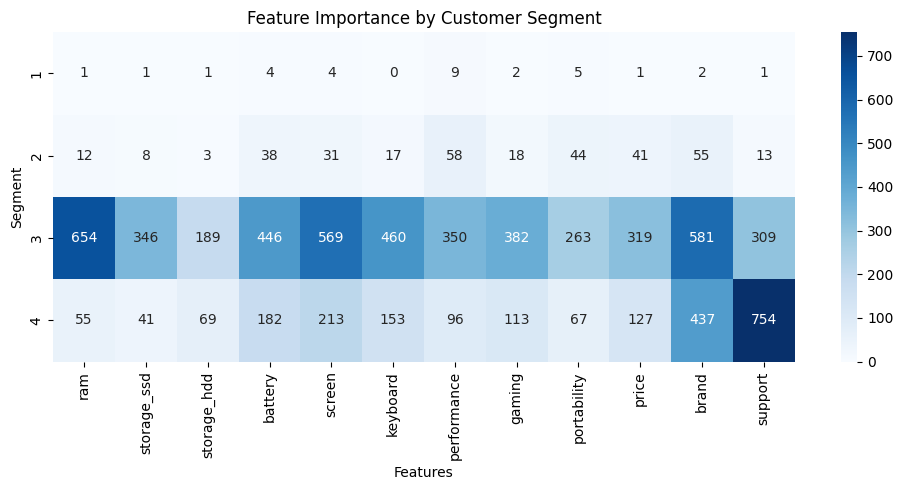

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# feature_df assumed to be:
# rows = segments
# columns = features
# values = frequency counts

plt.figure(figsize=(10,5))
sns.heatmap(
    feature_df,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Feature Importance by Customer Segment")
plt.xlabel("Features")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()